In [43]:
filepath = r'C:\Users\User\Online_retail_analysis\Online_Retail_csv.csv'

import pandas as pd
import numpy as np
from scipy.stats import iqr
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import sqlite3

df = pd.read_csv(filepath)


In [44]:
def clean_stockcode(df)->dict:
    clean_df = df[['StockCode','UnitPrice']].dropna()
    clean_df = df[df['UnitPrice'] > 0]
    global stock_prices_dict
    stock_prices_dict = dict(zip(clean_df.StockCode, clean_df.UnitPrice))
    
    return stock_prices_dict

df['UnitPrice'] = df.StockCode.map(clean_stockcode(df))


In [45]:
clean_description = df[df['Description'].notna() & df['Description'].str.isupper()]
stock_description_dict = dict(zip(clean_description.StockCode, clean_description.Description))

df['Description'] = df.StockCode.map(stock_description_dict)

In [46]:
df['date'] = pd.to_datetime(df.InvoiceDate, errors = 'coerce').dt.date
df['date'] = pd.to_datetime(df['date'], errors = 'coerce')
df['date'] = df.date.dt.to_period('M')
df['Invoice_Date'] = df.date.astype('str')

df['Revenue'] = (df['Quantity'] * df['UnitPrice']).round(3)

In [47]:
print(df.date.min(), df.date.max())

2010-12 2011-12


In [48]:
df['Month'] = df['date'].dt.month

MONTHS = ('January','February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', \
'October', 'November', 'December')
months_keys = [i for i in range(1,13)]
months_dict = dict(zip(months_keys, MONTHS))

df['Month'] = df['date'].dt.month.map(months_dict)
df['Month'] = df.Month.astype('category')
df['Month'] = df['Month'].cat.set_categories(new_categories= MONTHS, ordered= True)

In [49]:
df.dropna(subset= 'UnitPrice', inplace = True)

In [50]:
def outlier_filter(*series_1) -> tuple:
    '''Finds outlier for numerical Pandas Series of type float and int.
    Returns:
            Tuple(lower_bound, upper_bound) whereby lower bound can be found using oulier_filter('x')[0]
            and upper bound can be found using oulier_filter('x')[1]'''
    lower = np.quantile(series_1, 0.25)
    upper = np.quantile(series_1, 0.75)
    iqr = upper - lower
    lower_bound = lower - 1.5*iqr
    upper_bound = upper + 1.5*iqr
    return (lower_bound, upper_bound)


q1, q2 =  outlier_filter(df.loc[lambda x: x['Quantity'] > 0, ['Quantity']])
print(q1,q2)

-12.5 23.5


In [51]:
def validating_false_revenue_positive():
    valid_df = df[np.logical_and(df['Quantity'] < 0, df['UnitPrice'] < 0)]
    print(valid_df.shape[0])

validating_false_revenue_positive()



0


In [52]:
#Do not delete, this validates that there is truly some StockCodes with missing UnitPrices thus making them a /
#unique values that need to be dropped. They are less than 300 though out of dataset of over 500K rows.

empty_prices = df[df.UnitPrice.isna()]
validation_list = []
for key, value in stock_prices_dict.items():
    if key in empty_prices.StockCode:
        validation_list.append(key)

print(len(validation_list))

0


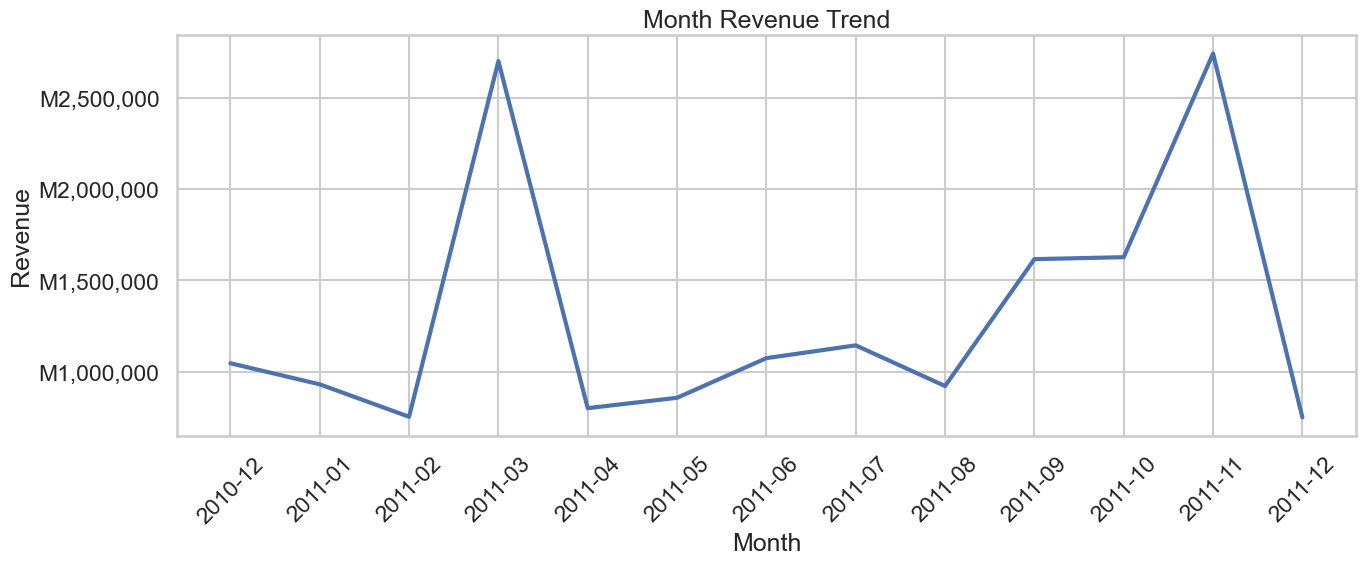

In [53]:
revenue_per_month = df.groupby('Invoice_Date')['Revenue'].sum().round(2).reset_index()

sns.set_theme(style= 'whitegrid', context= 'talk')
plt.figure(figsize=(14,6))
ax = sns.lineplot(data= revenue_per_month, x = 'Invoice_Date', y = 'Revenue',
                  markers= 'o', linewidth = 3)

plt.title('Month Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')


ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('M{x:,.0f}'))

plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()

In [54]:
number_of_purchases_pm = df.value_counts('Invoice_Date').reset_index()
number_of_returns_pm = df[df['Revenue'] < 0].value_counts('Invoice_Date').reset_index()
#print(number_of_returns_pm.head(13))

#print(df.loc[lambda x: x['Invoice_Date'] == '2011-03', ['Quantity']].describe())
march_dataset = df.loc[lambda x: x['Invoice_Date'] == '2011-03', :]
a, b = outlier_filter(march_dataset['Revenue'])
quantity_outliers = march_dataset[np.logical_or(march_dataset['Revenue'] < a, march_dataset['Revenue'] > b )]




In [55]:
month_revenue = df.groupby('Month', observed= False)['Revenue'].sum().round(2).reset_index()

In [60]:
unit_revenue = revenue_per_month.merge(right= number_of_purchases_pm, on= 'Invoice_Date', how = 'right')
unit_revenue['Unit_Revenue'] = round(unit_revenue.Revenue / unit_revenue['count'],2)
unit_revenue.head(14)

,Invoice_Date,Revenue,count,Unit_Revenue
0,2011-11,2743968.06,84710,32.39
1,2011-10,1627324.70,60733,26.79
2,2011-09,1616524.23,50225,32.19
3,2010-12,1045739.88,42466,24.63
4,2011-07,1143838.75,39503,28.96
5,2011-05,856337.57,37021,23.13
6,2011-06,1073765.95,36874,29.12
7,2011-03,2702555.90,36735,73.57
8,2011-08,920771.66,35284,26.10
9,2011-01,930148.07,35118,26.49


In [56]:
month_returns_per_country = df.loc[lambda x: x["Quantity"] < 0, :].groupby(['Month', 'Country'], observed= False)['Revenue'].sum().round(2).reset_index()

In [57]:
#purchases no. per country
purchases_per_country = df.Country.value_counts().to_dict()
returns_per_country = df.loc[lambda x: x["Quantity"] < 0, :].groupby(['Country'])['Revenue'].sum().round(2).reset_index()
returns_per_country_2 = df.loc[lambda x: x["Quantity"] < 0, :].groupby(['Country'])['Revenue'].sum().round(2).to_dict()
countries_that_returned = list(returns_per_country.Country)
returns_per_purchases = returns_per_country.loc[lambda x: x['Country'] == countries_that_returned]

returns_per_purchases['UnitsSold'] = returns_per_purchases.Country.map(returns_per_country_2)


"""Reminder to find returns per country ratio. This is also retention rate"""

'Reminder to find returns per country ratio. This is also retention rate'